<table align="left">
  <td>
    <a href="https://githubtocolab.com/flightcomp/eia/blob/main/moia/mnist-digit-classification-cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a href="https://kaggle.com/notebooks/welcome?src=https://github.com/flightcomp/eia/blob/main/moia/mnist-digit-classification-cnn.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" width="115"/></a>
  </td>
</table>

---

# **Licencia**

**Autor**: Roberto Chao Polo

**Licencia**: GPL v3 (https://www.gnu.org/licenses/gpl-3.0.html)

---
## Clasificador de dígitos con una red convolucional usando PyTorch

### Cargar el modelo y mostrar algunos ejemplos

Using device: cpu
Training samples: 60000
Test samples: 10000
Number of classes: 10


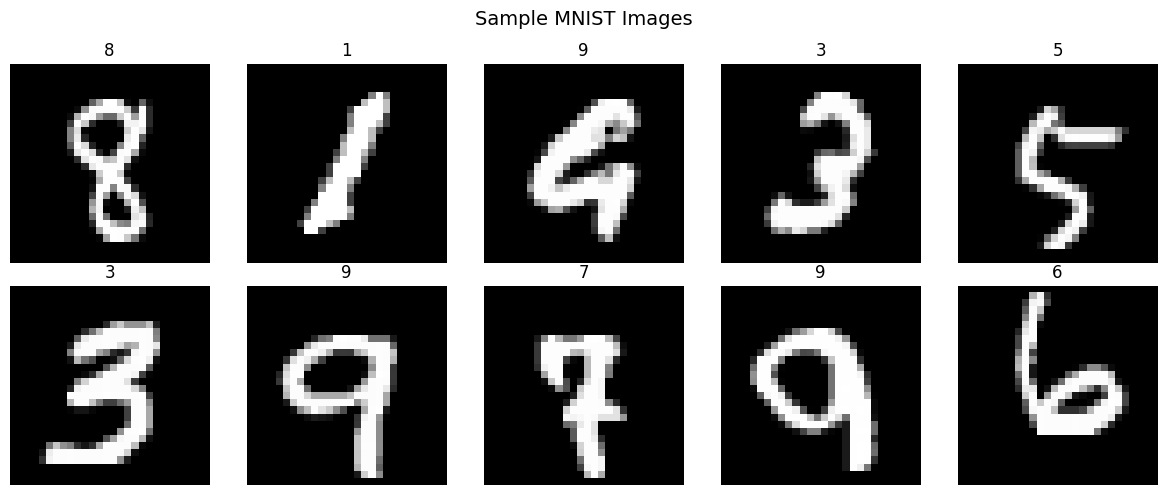

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
transform = transforms.Compose([
    transforms.ToTensor(), # normaliza entre 0 y 1
    transforms.Normalize((0.1307,), (0.3081,)) # media y desviación estándar del mnist dataset
])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)
classes = [str(i) for i in range(10)]
print(f'Training samples: {len(trainset)}')
print(f'Test samples: {len(testset)}')
print(f'Number of classes: {len(classes)}')
dataiter = iter(trainloader)
images, labels = next(dataiter)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(classes[labels[i]])
    ax.axis('off')
plt.suptitle('Sample MNIST Images', fontsize=14)
plt.tight_layout()
plt.show()

### Construye la red

In [2]:
from torchinfo import summary
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        #self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        #self.dropout = nn.Dropout(0.25)
        #self.fc1 = nn.Linear(128 * 3 * 3, 256)
        #self.fc2 = nn.Linear(256, 10)
        self.fc2 = nn.Linear(64 * 5 * 5, 10)
        self.apply(self._init_weights)
    def _init_weights(self, m):
        # Si la capa es Conv2d o Linear, aplicamos Xavier
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            # Keras suele inicializar los bias a cero
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        #x = self.pool(self.relu(self.conv3(x)))
        #x = x.view(-1, 128 * 3 * 3)
        x = x.view(-1, 64 * 5 * 5)
        #x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x
model = SimpleCNN().to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')
summary(model, input_size=(1, 1, 28, 28))

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc2): Linear(in_features=1600, out_features=10, bias=True)
)

Total parameters: 34,826


Layer (type:depth-idx)                   Output Shape              Param #
SimpleCNN                                [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 26, 26]           320
├─ReLU: 1-2                              [1, 32, 26, 26]           --
├─MaxPool2d: 1-3                         [1, 32, 13, 13]           --
├─Conv2d: 1-4                            [1, 64, 11, 11]           18,496
├─ReLU: 1-5                              [1, 64, 11, 11]           --
├─MaxPool2d: 1-6                         [1, 64, 5, 5]             --
├─Linear: 1-7                            [1, 10]                   16,010
Total params: 34,826
Trainable params: 34,826
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.47
Input size (MB): 0.00
Forward/backward pass size (MB): 0.24
Params size (MB): 0.14
Estimated Total Size (MB): 0.38

La fórmula para el cálculo de parámetros en una capa convolucional es:

parámetros = (filtros de entrada × ancho_kernel × alto_kernel + 1) × filtros de salida
### Define la función de pérdida y entrenalo

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, eps=1e-08)
print('Loss: CrossEntropyLoss')
print('Optimizer: Adam (lr=0.001)')
num_epochs = 3
train_losses = []
train_accuracies = []
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        # Zero de parameter gradients
        optimizer.zero_grad()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / len(trainloader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    print(f'Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')
print('\nTraining complete!')

Loss: CrossEntropyLoss
Optimizer: Adam (lr=0.001)
Epoch [1/3] - Loss: 0.0024, Accuracy: 99.92%
Epoch [2/3] - Loss: 0.0030, Accuracy: 99.90%
Epoch [3/3] - Loss: 0.0010, Accuracy: 99.97%

Training complete!


### Muestra las curvas de pérdida y la métrica de exactitud

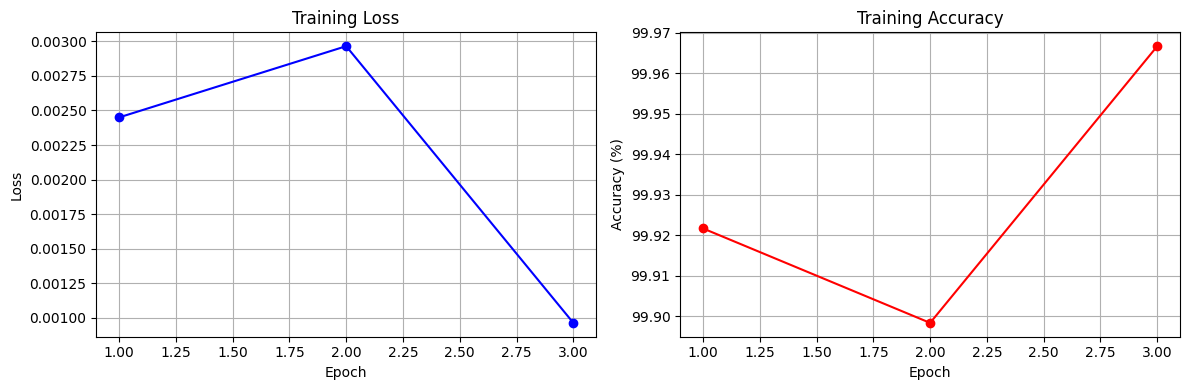

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(range(1, num_epochs+1), train_losses, 'b-o')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)
ax2.plot(range(1, num_epochs+1), train_accuracies, 'r-o')
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True)
plt.tight_layout()
plt.show()

### Carga el modelo

In [31]:
state_dict = torch.load('data/mnist_cnn_model.pth', map_location=device)

# 3. Carga los pesos en la instancia del modelo
model.load_state_dict(state_dict)

<All keys matched successfully>

### Calcula la exactitud sobre el conjunto de prueba
Al llamar a
iter(dataloader), PyTorch crea y devuelve un objeto iterador (técnicamente un _BaseDataLoaderIter).
Este objeto es el encargado de gestionar el ciclo de vida de la carga de datos: activa los workers en paralelo, aplica las transformaciones y agrupa las muestras en lotes (batches).
Lo más importante es qué obtienes cuando pides el siguiente elemento de ese iterador:

1. Un lote de datos (Batch): Cada vez que ejecutas next(iterador), recibes un lote con el tamaño definido en batch_size.
2. Estructura de Tensores: Generalmente devuelve una lista o un diccionario de tensores (dependiendo de cómo esté definido tu Dataset). Lo más común es: [tensores_de_entrada, tensores_de_etiquetas].
3. Dimensiones: El primer eje de estos tensores será siempre el tamaño del batch (ej. [64, 1, 28, 28]).

En PyTorch no existe un método .predict() nativo que gestione automáticamente todo el proceso (pasar a GPU, desactivar gradientes, concatenar resultados) como lo hace Keras. PyTorch es "imperativo", por lo que espera que tú controles el flujo.

In [32]:
model.eval() # Desactiva Dropout y BatchNorm
correct = 0
total = 0
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images) # Devuelve logits o sumas ponderadas mientras keras devuelve las activaciones o probabilidades
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
test_accuracy = 100 * correct / total
print(f'Test Accuracy: {test_accuracy:.2f}%')

Test Accuracy: 99.18%


### Calcula la exactitud para cada clase

In [26]:
class_correct = [0] * 10
class_total = [0] * 10
for pred, label in zip(all_preds, all_labels):
    class_total[label] += 1
    if pred == label:
        class_correct[label] += 1
print('Per-class accuracy:')
print('-' * 30)
for i in range(10):
    acc = 100 * class_correct[i] / class_total[i]
    print(f'{classes[i]:>2s}: {acc:.1f}%')

Per-class accuracy:
------------------------------
 0: 99.6%
 1: 99.5%
 2: 99.3%
 3: 99.4%
 4: 99.6%
 5: 99.2%
 6: 99.0%
 7: 99.6%
 8: 99.2%
 9: 97.4%


### Muestra un resumen de la clasificación

In [27]:
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=classes))


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      0.99      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.98      1.00      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



### Matriz de confusion

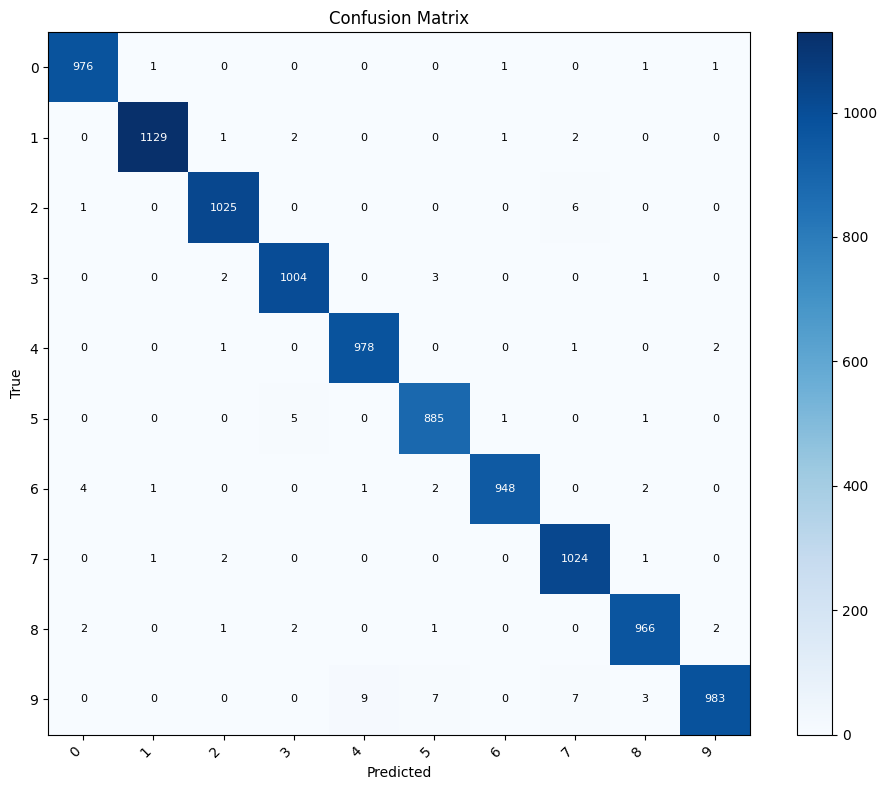

In [28]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.set_title('Confusion Matrix')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.set_yticklabels(classes)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
for i in range(10):
    for j in range(10):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=8)
plt.tight_layout()
plt.show()

### Muestra casos donde el modelo se confunde

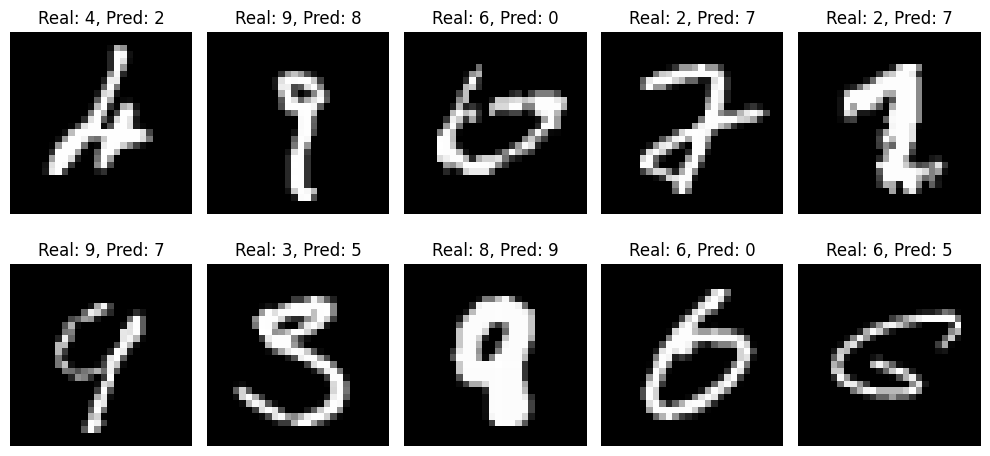

In [29]:
indices_confundidos = [i for i, (a, b) in enumerate(zip(all_labels, all_preds)) if (a != b)][:10]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    idx = indices_confundidos[i]
    image, label = testloader.dataset[idx]
    img = image.squeeze().numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Real: {classes[label]}, Pred: {classes[all_preds[idx]]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

### Salva el modelo a un archivo

In [30]:
torch.save(model.state_dict(), 'data/mnist_cnn_model.pth')
print('Model saved to mnist_cnn_model.pth')

Model saved to mnist_cnn_model.pth
